# Livestock data generation

This notebook contains the methodology for processing livestock data contained in [paper]. The objective of this analysis to map cattle counts onto the world's countries, and update a spatial distribution of cattle count from 2006 to match 2017 data.

## Resources

The raw datasets used in this analysis are as follows:

In [419]:
CGIAR_CATTLE_DATA = "https://osf.io/hwabr/download"
FAO_CATTLE_DATA = "https://osf.io/ewtna/download"
COUNTRY_BOUNDARY_DATA = "https://osf.io/p93yg/download"

---

## Read in and count CGIAR data (2006 - spatial)

First we'll read in the raw livestock data from CGIAR

In [420]:
# Allow access to Python imports from higher level folder
from allfed_spatial.raster.conversions import raster_to_features

# Read livestock dataset located at https://osf.io/tdzfy
# This is a .tif file showing the global distribution of cattle (head / square km.)
points = raster_to_features(CGIAR_CATTLE_DATA)

`points` is our raster file with values discretised into points at the centroid of each pixel. The value (in head / sq. km.) and area that the point covers (in sq. km.) are stored in the `data` attribute for each point:


Total head of cattle in the CGIAR dataset is therefore:

In [422]:
global_cattle_count_2006 = sum([p.data['value'] * p.data['pixel_size'] for p in points])
print("{:,} head".format(round(global_cattle_count_2006)))

1,406,035,834 head


---
## Read in and count FAO data (2017 - non-spatial)

The CGIAR total value is for 2006, with the point distribution being used to generate it being the most recent set of spatial data available for livestock. Having the spatial data is important as it will allow us to make localised observations about livestock prevalence and compare this with other datasets such as crop distributions. However, it is desirable to update this data to best reflect the most recent total numbers on global cattle head count. To update this distribution to reflect the most recent non-spatial figure on record (FAO, 2017, 1.49 billion), we can use a technique called spatial disaggregation. This consists of:

1. Breaking down the FAO number into it's smallest spatial components (numbers for each country for 2017)
2. Using this country data to proportionally update our point-based data based on a spatial intersection with country boundaries

To fo this, we'll first load the country data for cattle:


In [423]:
import pandas as pd
global_cattle_by_country_2017 = pd.read_csv(FAO_CATTLE_DATA)

This data has some doubling up with values in China - stating values for "China", "China, mainland" and "China Hong Kong SAR". We'll remove "China, mainland", and update "China, Taiwan Province of" to avoid confusion with the FAO country boundary dataset (see next section)

In [424]:
global_cattle_by_country_2017.loc[37:42]

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description
37,QA,Live Animals,40,Chile,5111,Stocks,866,Cattle,2017,2017,Head,2890840.0,NaN,Official data
38,QA,Live Animals,351,China,5111,Stocks,866,Cattle,2017,2017,Head,83355177.0,A,"Aggregate, may include official, semi-official..."
39,QA,Live Animals,96,"China, Hong Kong SAR",5111,Stocks,866,Cattle,2017,2017,Head,1584.0,Im,FAO data based on imputation methodology
40,QA,Live Animals,41,"China, mainland",5111,Stocks,866,Cattle,2017,2017,Head,83209600.0,F,FAO estimate
41,QA,Live Animals,214,"China, Taiwan Province of",5111,Stocks,866,Cattle,2017,2017,Head,143993.0,NaN,Official data
42,QA,Live Animals,44,Colombia,5111,Stocks,866,Cattle,2017,2017,Head,22461179.0,Im,FAO data based on imputation methodology


In [425]:
df = global_cattle_by_country_2017.drop(global_cattle_by_country_2017.index[[40]]);

# Some other data-set correlation helpers
df = df.replace("Democratic People's Republic of Korea", "Dem People's Rep of Korea")
df = df.replace("Congo", "Republic of the Congo (ROC)")
df = df.replace("Eswatini", "Swaziland")
df = df.replace("Georgia", "Georgia (Europe)")
df = df.replace("Ireland", "Ireland (Independent)")
df = df.replace("Libya", "Libyan Arab Jamahiriya")
df = df.replace("Palestine", "Libyan Arab Jamahiriya")
df = df.replace("United Kingdom", "U.K. of Great Britain and Northern Ireland")
df = df.replace("American Samoa", "AmericanSamoa")
df = df.replace("Equatorial Guinea", "EquatorialGuinea")
df = df.replace("Guinea", "Guinea (West Africa)")

Total head of cattle in the FAO dataset is therefore:

In [426]:
global_cattle_count_2017 = int(df['Value'].sum())
print("{:,} head".format(round(global_cattle_count_2017)))

1,491,832,816 head


---
## Match FAO data to country boundaries

Now we'll associate the FAO data back to the actual spatial boundaries that make up each country in the dataset. First, we'll load some country boundary polygons from FAO (this may take a couple of minutes).

In [427]:
from allfed_spatial.features.io import load_features
country_boundaries = load_features(COUNTRY_BOUNDARY_DATA)

{'ADM0_NAME': 'Afghanistan'}


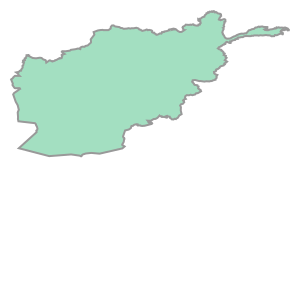

In [428]:
print(country_boundaries[0].data)
country_boundaries[0].geom

Now we'll match up each entry in the FAO cattle population table with a feature in the country boundary dataset. Note that some names may not be an exact match so we'll need to do some "fuzzy" text matching:

In [429]:
from fuzzywuzzy import fuzz, process

We have a dataframe of cattle populations by country, and a set of country spatial boundaries that we want to match these to. To match them, we'll iterate through our by-country cattle populations, find the country boundary with the closest matching name, determine whether it's a true match, and if so allocate the relevant cattle population to that boundary.

In [430]:
# look up dicts based on name for cattle population (head) and boundaries
head_by_country = dict(zip(df['Area'].tolist(), df['Value']))
boundaries_by_country = {cb.data['ADM0_NAME']: cb for cb in country_boundaries}

ref = set(boundaries_by_country.keys()) # used for name matching - delete entries from here when matched

# Remove disputed territories with no cattle population
ref.remove('China/India')

for c in head_by_country.keys():
    if c in ref:
        matching_boundary_name = c
    else:
        matching_boundary_name, score = process.extractOne(c, ref, scorer=fuzz.token_set_ratio)

    ref.remove(matching_boundary_name)
    boundaries_by_country[matching_boundary_name].update_data('cattle_count_2017', head_by_country[c])
    boundaries_by_country[matching_boundary_name].update_data('cattle_count_2006', 0)


We've now got our FAO 2017 cattle data matched to our boundaries.

In [431]:
boundaries_by_country['Australia'].data

{'ADM0_NAME': 'Australia',
 'cattle_count_2017': 26175521.0,
 'cattle_count_2006': 0}

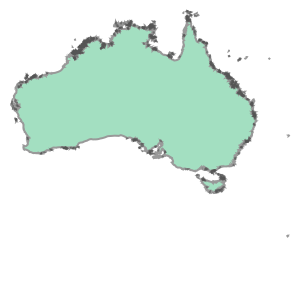

In [432]:
boundaries_by_country['Australia'].geom

---

## Match CGIAR data to country boundaries

Now we'll find the total cattle count for each country for 2006 - this will come from our high resolution point values from the CGIAR data.

In [433]:
from allfed_spatial.features.conversions import features_to_geodataframe
import numpy as np

In [434]:
# Convert points and country boundaries to geodataframes
point_gdf = features_to_geodataframe(points)
boundaries_gdf = features_to_geodataframe(list(boundaries_by_country.values()))
point_gdf['point_cattle_count_2006'] = point_gdf['value'] * point_gdf['pixel_size']
point_gdf = point_gdf[['geometry', 'point_cattle_count_2006']]

In [435]:
# Fill in NaN values with 0s
boundaries_gdf['cattle_count_2017'] = boundaries_gdf['cattle_count_2017'].fillna(0)
boundaries_gdf['cattle_count_2006'] = boundaries_gdf['cattle_count_2006'].fillna(0)

In [436]:
# Spatially join points to boundaries
points_in_boundaries = gpd.sjoin(point_gdf, boundaries_gdf, op="within")
all_points = points_in_boundaries.merge(point_gdf, how='outer')

In [437]:
# Group points by the boundary they are in, then sum to get per country counts - note that this will exclude any
# points not inside a boundary (totalling around 6 million head of cattle)
values_by_country = all_points.groupby(['ADM0_NAME'])['point_cattle_count_2006'].agg('sum')

In [438]:
# Merge with the values_by_country data to get the 2017 counts
gdf = boundaries_gdf.merge(values_by_country, left_on='ADM0_NAME', right_on='ADM0_NAME', how='outer')

In [439]:
# Re-format
gdf['cattle_count_2017'] = gdf['cattle_count_2017'].astype('int32')
gdf['cattle_count_2006'] = gdf['point_cattle_count_2006'].fillna(0).astype('int32')
gdf = gdf[['ADM0_NAME', 'cattle_count_2017', 'cattle_count_2006', 'geometry']]

In [440]:
# Get absolute difference and ratio between 2017 and 2006 cattle counts
gdf['diff'] = gdf['cattle_count_2017'] - gdf['cattle_count_2006']
gdf['ratio'] = gdf['cattle_count_2017'] / gdf['cattle_count_2006']
gdf = gdf.replace([np.inf, -np.inf], np.nan)
gdf['ratio'] = gdf['ratio'].fillna(1)

In [ ]:
# Write
gdf.to_file("../data/processed/global_cattle_boundaries.gpkg", driver="GPKG")

---
## Update point data to 2017

Now we'll use the ratios between the 2017 and 2006 counts to update our point data

In [441]:
# Merge with the boundary geodataframe to get ratio between 2006 and 2007
updated_points = all_points.merge(gdf, left_on='ADM0_NAME', right_on='ADM0_NAME', how='outer')

In [442]:
# Re-format
updated_points = updated_points[['ADM0_NAME', 'geometry_x', 'point_cattle_count_2006', 'ratio']]
updated_points.columns = ['ADM0_NAME', 'geometry', 'point_cattle_count_2006', 'ratio']

In [443]:
# Update 2017 counts based on ratio
updated_points['ratio'] = updated_points['ratio'].fillna(1)
updated_points['point_cattle_count_2017'] = updated_points['point_cattle_count_2006'] * updated_points['ratio']

In [444]:
# Turn into geodataframe
updated_points_gdf = gpd.GeoDataFrame(updated_points, geometry='geometry')

In [445]:
# Write
updated_points_gdf.to_file("../data/processed/global_cattle_points.gpkg", driver="GPKG")